# Fine-tunung Stable diffusion using HuggingFace Diffusers

- Reference:
    - https://github.com/metamath1/pytorch-stable-diffusion-fine-tuning

## Step 1

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torchvision import transforms
import transformers, datasets, diffusers
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from diffusers.optimization import get_scheduler
from diffusers import StableDiffusionPipeline

from tqdm import tqdm
from PIL import Image


print(f"transformers version : {transformers.__version__}")
print(f"datasets version     : {datasets.__version__}")
print(f"diffusers version    : {diffusers.__version__}")

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"device {device}")

W1004 11:24:22.608000 63701 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


transformers version : 4.56.2
datasets version     : 4.1.1
diffusers version    : 0.35.1
device mps


## Step 2 : Download SD model from Huggingface


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

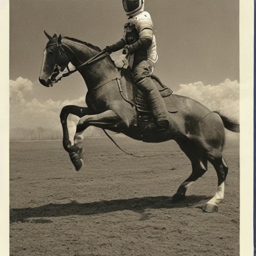

In [2]:
PRE_TRAINED_MODEL_NAME="sd-legacy/stable-diffusion-v1-5"

origin_pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME)
origin_pipe = origin_pipe.to(device)
prompt = " a photograph of an astronaut riding a horse"
origin_image = origin_pipe(prompt).images[0].resize((256, 256))

origin_image

In [3]:
noise_scheduler = DDPMScheduler.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="scheduler"
)

tokenizer = CLIPTokenizer.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="tokenizer"
)

# Frozen
text_encoder = CLIPTextModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="text_encoder"
)

# Frozen
vae = AutoencoderKL.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="vae"
)

# Will be fine-tuned
unet = UNet2DConditionModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="unet"
)


## Step 3. Download training data for fine-tuning

140-th Image Size: (1280, 1280)
140-th Caption   : a very cute looking cartoon character with big eyes


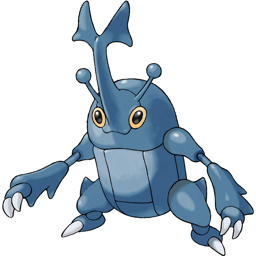

In [39]:
dataset = datasets.load_dataset("xiaoqia/poken")
idx = 140
print(f"{idx}-th Image Size: {dataset['train'][idx]['image'].size}")
print(f"{idx}-th Caption   : {dataset['train'][idx]['text']}")
dataset['train'][idx]['image'].resize((256, 256))

## Step 4. Data Loader

### Step 4.1 Preprocessing for Text

In [5]:
# Check the max_length of tokenizer
print(f"the max_length of tokenizer : {tokenizer.model_max_length}")

# Test tokenizer
token = tokenizer(dataset['train'][idx]['text'],
                  max_length=tokenizer.model_max_length,
                  padding='max_length',
                  truncation=True,
                  return_tensors='pt')
print(f" -- Text  : {dataset['train'][idx]['text']}")
print(f" >> Token : {token}")

# Preprocessing for caption tokenize
def tokenize_captions(examples, caption_column='text', is_train=True):
    captions = []

    for caption in examples[caption_column]:
        # one caption
        if isinstance(caption, str):
            captions.append(caption)
        # multiple caption
        elif isinstance(caption, (list, np.ndarray)):
            # take a random caption if there are multiple
            captions.append(random.choice(caption) if is_train else caption[0])
        else:
            raise ValueError(
                f"Caption column `{caption_column}` should contain either strings or lists of strings."
            )

    inputs = tokenizer(
        captions, max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="pt"
    )

    return inputs.input_ids

the max_length of tokenizer : 77
 -- Text  : a very cute looking cartoon character with big eyes
 >> Token : {'input_ids': tensor([[49406,   320,  1070,  2242,  1312,  7651,  4009,   593,  1205,  3095,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
  

### Step 4.2 Preprocessing for Image


In [6]:
IMG_SIZE = 512
CENTER_CROP = True
RANDOM_FLIP = True

# Preprocessing the datasets.
train_transforms = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMG_SIZE) if CENTER_CROP else transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip() if RANDOM_FLIP else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]), # (0,1)->(-1,1)
    ]
)

### Step 4. 3 Apply the preprocess function to dataset

In [7]:
def preprocess_train(examples, image_column='image'):
    images = [image.convert("RGB") for image in examples[image_column]]

    # preprocessing for image
    examples["pixel_values"] = [train_transforms(image) for image in images]

    # preprocessing for text
    examples["input_ids"] = tokenize_captions(examples)

    return examples



# apply preprocess_train at train dataset
train_dataset = dataset["train"].with_transform(preprocess_train)

# check dataset
print(f"Data fields : {train_dataset.column_names}")
print(f"Data keys   : {train_dataset[0].keys()}")





Data fields : ['image', 'text']
Data keys   : dict_keys(['image', 'text', 'pixel_values', 'input_ids'])


### Step 4.4 DataLoader

In [ ]:
def collate_fn(examples):
    # (C, H, W), ..., (C, H, W) -> stack -> (N, C, H, W)
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    # tensor.contiguous()
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()

    # {(77,), ..., (77,)}_N -> stack -> (N, 77)
    input_ids = torch.stack([example["input_ids"] for example in examples])

    return {"pixel_values": pixel_values, "input_ids": input_ids}


# 데이터로더 생성

BATCH_SIZE = 2 # 2 for rtx 3090
NUM_WORKERS = 1 # 4 for rtx 3090

# DataLoaders creation:
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
    # num_workers=NUM_WORKERS,
)

# Test Dataloader
train_dataloader_iter = iter(train_dataloader)
mini_batch = next(train_dataloader_iter)

print(f"Image shape     : {mini_batch['pixel_values'].shape}")
print(f"Text data shape : {mini_batch['input_ids'].shape}")
print(f"The number of iteration : {len(train_dataloader)}")
print(f"The shape of text encoder : {text_encoder(mini_batch['input_ids'])[0].shape}")


Image shape     : torch.Size([2, 3, 512, 512])
Text data shape : torch.Size([2, 77])
The number of iteration : 417
The shape of text encoder : torch.Size([2, 77, 768])


## Step 5. Training

### Setup 5.1. Update the status of models for fine-tuning

In [9]:
# For FP16 : weight_dtype = torch.float32
# weight_dtype = torch.float16 # half precision

# Freeze vae and text encoder
vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# Move text_encode and vae to gpu/mps
text_encoder.to(device)
vae.to(device)
unet.to(device)


unet.train()


UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

### 5.2. Setup Optimizer and Scheduler

In [10]:
EPOCHS = 30
LEARNING_RATE = 1e-05

# Setup Optimizer
optimizer = torch.optim.AdamW(
        unet.parameters(),
        lr=LEARNING_RATE,
    )
# Setup Scheduler
lr_scheduler = get_scheduler(
        'linear',
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=EPOCHS * len(train_dataloader)
    )

## Step 10


In [ ]:
from pathlib import Path
Path("temp/sd_model").mkdir(parents=True, exist_ok=True)


use_amp = False
prediction_type = None # 'epsilon'  or 'v_prediction'

train_losses = []

for epoch in range(EPOCHS):
    for step, batch in enumerate(tqdm(train_dataloader)):
        # pytorhc amp autocast
        # with torch.autocast(device_type=device, dtype=weight_dtype, enabled=use_amp):
        # Convert images to latent space
        latents = vae.encode(
            batch["pixel_values"].to(device)
        ).latent_dist.sample()
        latents = latents * vae.config.scaling_factor

        # --------
        # Sample noise that we'll add to the latents
        noise = torch.randn_like(latents)

        bsz = latents.shape[0]
        # Sample a random timestep for each image
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device)
        timesteps = timesteps.long()

        # Add noise to the latents according to the noise magnitude at each timestep
        # (this is the forward diffusion process)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Get the text embedding for conditioning, [0]: last_hidden_state
        encoder_hidden_states = text_encoder(batch["input_ids"].to(device) )[0]

        # Set targets in the noise scheduler based on whether the prediction type is noise or image.
        if prediction_type is not None:
            # set prediction_type of scheduler if defined
            noise_scheduler.register_to_config(prediction_type=prediction_type)

        if noise_scheduler.config.prediction_type == "epsilon":
            target = noise
        elif noise_scheduler.config.prediction_type == "v_prediction":
            target = noise_scheduler.get_velocity(latents, noise, timesteps)
        else:
            raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")

        # Predict the noise residual and compute loss
        model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")


        with torch.no_grad():
            train_losses.append(loss.item())

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()
        # lr_scheduler.step()
        # optimizer.zero_grad()

    # print loss
    avg_loss = sum(train_losses[-100:])/100
    print(f'Finished epoch {epoch+1}. Average of the last 100 loss values: {avg_loss:05f}')
    unet.save_pretrained("temp/sd_model")

100%|██████████| 417/417 [27:07<00:00,  3.90s/it] 


Finished epoch 1. Average of the last 100 loss values: 0.053782


100%|██████████| 417/417 [21:48<00:00,  3.14s/it] 


Finished epoch 2. Average of the last 100 loss values: 0.056243


100%|██████████| 417/417 [20:12<00:00,  2.91s/it]


...

Finished epoch 28. Average of the last 100 loss values: 0.050216


100%|██████████| 417/417 [18:16<00:00,  2.63s/it]


Finished epoch 29. Average of the last 100 loss values: 0.046423


100%|██████████| 417/417 [23:51<00:00,  3.43s/it]


Finished epoch 30. Average of the last 100 loss values: 0.047870


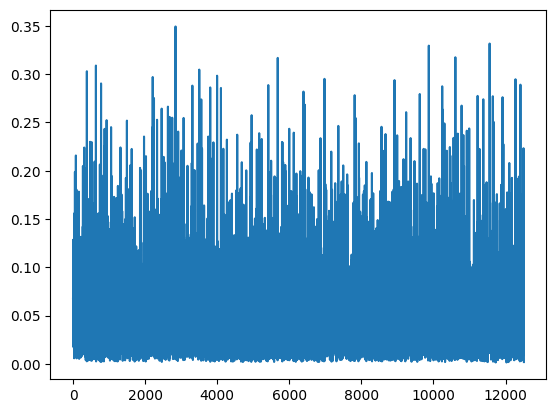

In [12]:
plt.plot(train_losses)
plt.show()

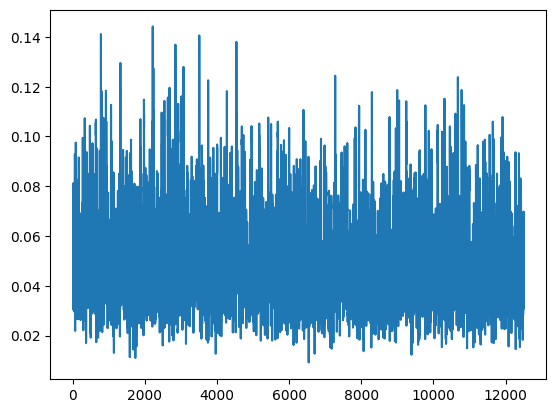

In [13]:
import pandas as pd
losses_sr = pd.Series(train_losses)
loss_mv = losses_sr.rolling(window=5).mean()

plt.plot(loss_mv)

In [ ]:
prompt = ["a very cute looking cartoon character with big eyes"]

height = 512  # default height of Stable Diffusion
width = 512  # default width of Stable Diffusion

num_inference_steps = 25  # Number of denoising steps
guidance_scale = 7.5  # Scale for classifier-free guidance

generator = torch.manual_seed(2)  # Seed generator to create the initial latent noise

batch_size = len(prompt)

text_input = tokenizer(
    prompt, max_length=tokenizer.model_max_length,
    padding="max_length", truncation=True, return_tensors="pt"
)


print(len(text_input['input_ids'][0]))

text_input

77


{'input_ids': tensor([[49406,   320,  1070,  2242,  1312,  7651,  4009,   593,  1205,  3095,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0]])}

In [ ]:
with torch.no_grad():
    text_embeddings = text_encoder(text_input['input_ids'].to(device))[0]


text_embeddings.shape

max_length = text_input['input_ids'].shape[-1]


uncond_input = tokenizer([""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt")

uncond_embeddings = text_encoder(uncond_input['input_ids'].to(device))[0]

# (1, 77, 768), (1, 77, 768) => (2, 77, 768)
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])


text_embeddings.shape

latents = torch.randn(
    (batch_size, unet.config.in_channels, height // 8, width // 8),
    generator=generator,
).to(device)


noise_scheduler.set_timesteps(num_inference_steps)
noise_scheduler.timesteps

tensor([961, 921, 881, 841, 801, 761, 721, 681, 641, 601, 561, 521, 481, 441,
        401, 361, 321, 281, 241, 201, 161, 121,  81,  41,   1])

In [16]:
for t in tqdm(noise_scheduler.timesteps):
    # expand the latents if we are doing classifier-free guidance to avoid doing two forward passes.
    latent_model_input = torch.cat([latents] * 2)

    # predict the noise residual
    with torch.no_grad():
        noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

    # perform guidance
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    # CFG eq(6)
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

    # compute the previous noisy sample x_t -> x_t-1
    latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

100%|██████████| 25/25 [00:12<00:00,  2.00it/s]


torch.Size([1, 3, 512, 512])


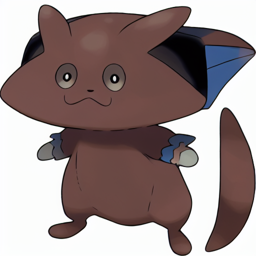

In [ ]:

latents = 1 / 0.18215 * latents
with torch.no_grad():
    image = vae.decode(latents).sample

print(image.shape)

image = (image / 2 + 0.5).clamp(0, 1).squeeze()
image = (image.permute(1, 2, 0) * 255).to(torch.uint8).cpu().numpy()

image = Image.fromarray(image).resize((256, 256))
image

In [ ]:
from diffusers import StableDiffusionPipeline

pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)

pipeline.to(device)

pipeline_output = pipeline("a very cute looking cartoon character with big eyes")



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

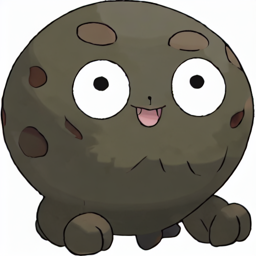

In [19]:
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/50 [00:00<?, ?it/s]

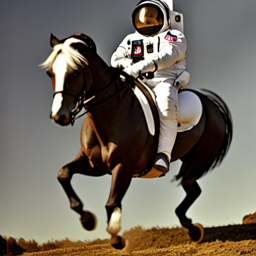

In [20]:
pipeline_output = pipeline("a photograph of an astronaut riding a horse")
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/50 [00:00<?, ?it/s]

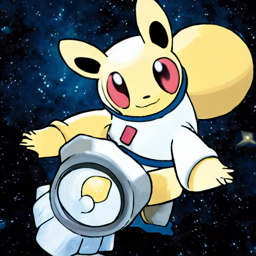

In [21]:
pipeline_output = pipeline(["a photograph of an astronaut riding a pokemon"])
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/50 [00:00<?, ?it/s]

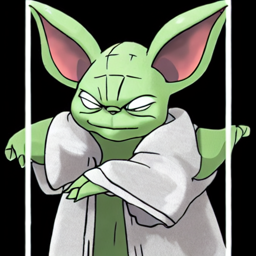

In [23]:
pipeline_output = pipeline(["Yoda"])
pipeline_output.images[0].resize((256, 256))

In [28]:
pipeline.save_pretrained("temp/sd_ft_pipeline")


  0%|          | 0/50 [00:00<?, ?it/s]

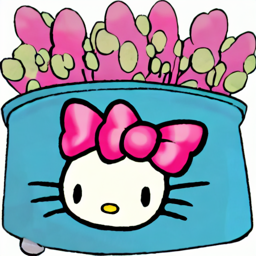

In [29]:
pipeline_output = pipeline(["Hello Kitty"])
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

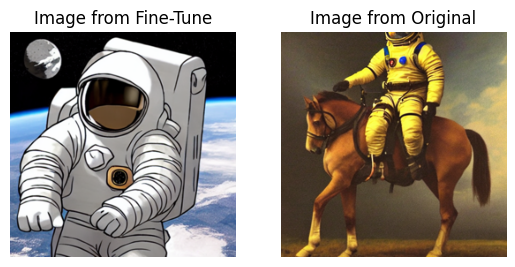

In [31]:
prompt_text = "a photograph of an astronaut riding a horse"

pipeline_output = pipeline([prompt_text])
pipeline_output.images[0]
o_output = origin_pipe([prompt_text])
o_output.images[0]

plt.subplot(1, 2, 1)
plt.imshow(pipeline_output.images[0].resize((256, 256)))
plt.axis('off')
plt.title("Image from Fine-Tune")
plt.subplot(1, 2, 2)
plt.imshow(o_output.images[0].resize((256, 256)))
plt.title("Image from Original")
plt.axis('off')
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

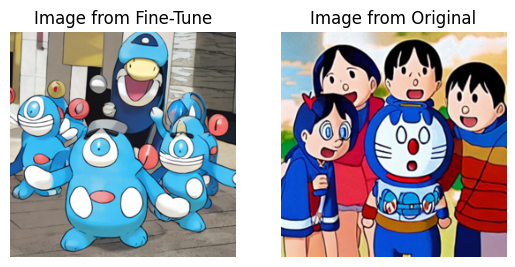

In [32]:
prompt_text = "a photograph of doraemon with friends"

pipeline_output = pipeline([prompt_text])
pipeline_output.images[0]
o_output = origin_pipe([prompt_text])
o_output.images[0]

plt.subplot(1, 2, 1)
plt.imshow(pipeline_output.images[0].resize((256, 256)))
plt.title("Image from Fine-Tune")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(o_output.images[0].resize((256, 256)))
plt.title("Image from Original")
plt.axis('off')
plt.show()